# 03 - 非线性最小二乘变换

本 Notebook 演示：
1. 多项式变换的拟合（逐特征，逐块）
2. 幂次变换（非线性最小二乘）
3. 精确 Gamma 直接应用（推荐方式）
4. 变换拟合效果可视化

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

from data.load_dataset import load_orl, train_test_split_orl
from src.biclustering import BidirectionalClustering
from src.reconstruction import reconstruct_all_blocks
from src.transform import (
    fit_block_transform, apply_block_transform_batch,
    fit_all_transforms, apply_all_transforms
)

X, y = load_orl(data_dir='../data/ORL')
X_train, X_test, y_train, y_test = train_test_split_orl(X, y, n_train=5)
IMG_SHAPE = (64, 64)
print(f'Training set: {X_train.shape}')

Training set: (200, 4096)


In [2]:
# 准备：双向聚类 + 块重构
bicluster = BidirectionalClustering(n_row_clusters=4, n_col_clusters=4, random_state=42)
bicluster.fit(X_train)
blocks, row_idx_map, col_idx_map = bicluster.get_blocks(X_train)
X_hat_train, block_params = reconstruct_all_blocks(X_train, blocks, row_idx_map, col_idx_map)
print("Block reconstruction done")

Block reconstruction done


## 1. 多项式变换拟合

In [3]:
# 选取最大块做单块演示
block_sizes = {k: v.shape[0] * v.shape[1] for k, v in blocks.items()}
a, b = max(block_sizes, key=block_sizes.get)
row_idx = row_idx_map[(a, b)]
col_idx = col_idx_map[(a, b)]

X_orig_block = X_train[np.ix_(row_idx, col_idx)]
X_hat_block  = X_hat_train[np.ix_(row_idx, col_idx)]
gamma_ab = block_params[(a, b)]["gamma"]

print(f"Block ({a},{b}): shape={X_orig_block.shape}, gamma={gamma_ab:.4f}")

params_poly = fit_block_transform(X_orig_block, X_hat_block, degree=2, use_nonlinear=False)
print(f"Poly params shape={params_poly.shape}")
print("First 5 features (theta_0, theta_1, theta_2):")
print(params_poly[:5])

Block (3,3): shape=(69, 1621), gamma=1.2518
Poly params shape=(1621, 3)
First 5 features (theta_0, theta_1, theta_2):
[[-0.06023201  0.85678977  0.20479542]
 [-0.06121111  0.85959625  0.20280415]
 [-0.06228155  0.86253363  0.20080358]
 [-0.0599521   0.85676014  0.20429038]
 [-0.05673715  0.84807539  0.21004382]]


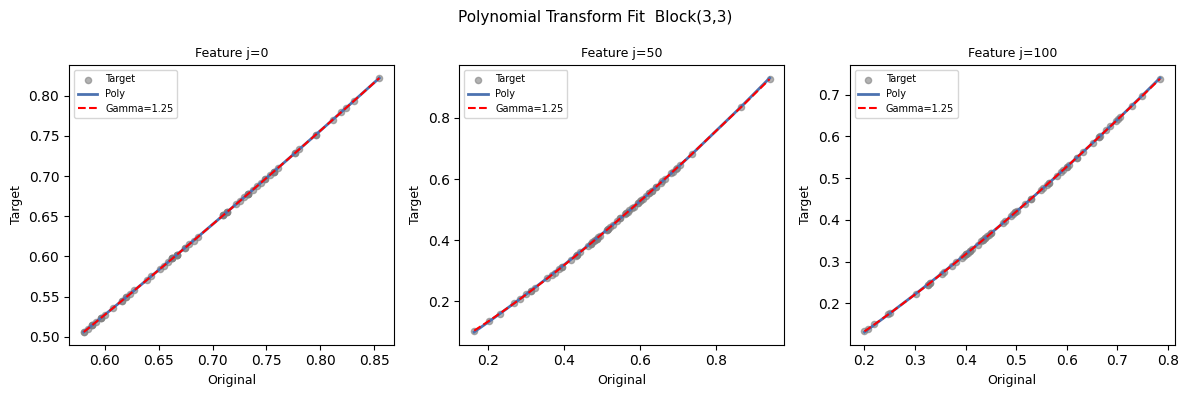

In [4]:
X_transformed_poly = apply_block_transform_batch(X_orig_block, params_poly, use_nonlinear=False)
X_transformed_gamma = apply_block_transform_batch(X_orig_block, params_poly, gamma_direct=gamma_ab)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for plot_idx, feat_j in enumerate([0, 50, min(100, X_orig_block.shape[1]-1)]):
    z = X_orig_block[:, feat_j]
    y_t = X_hat_block[:, feat_j]
    sort_idx = np.argsort(z)
    ax = axes[plot_idx]
    ax.scatter(z, y_t, alpha=0.6, s=20, color="gray", label="Target")
    ax.plot(z[sort_idx], X_transformed_poly[:, feat_j][sort_idx], color="#4c72b0", lw=2, label="Poly")
    ax.plot(z[sort_idx], X_transformed_gamma[:, feat_j][sort_idx], color="red", lw=1.5, ls="--", label=f"Gamma={gamma_ab:.2f}")
    ax.set_xlabel("Original", fontsize=9)
    ax.set_ylabel("Target", fontsize=9)
    ax.set_title(f"Feature j={feat_j}", fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle(f"Polynomial Transform Fit  Block({a},{b})", fontsize=11)
plt.tight_layout()
plt.savefig("../results/figures/03_poly_transform_fit.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. 幂次变换（非线性最小二乘）

Fitting power transform...
Power params shape=(50, 2)
First 5 (alpha_j, gamma_j):
[[0.99999999 1.25183519]
 [0.99999999 1.25183517]
 [0.99999997 1.25183512]
 [0.99999997 1.25183513]
 [0.99999998 1.25183516]]
Poly MSE:   0.000000
Power MSE:  0.000000
Direct Gamma MSE: 0.000000


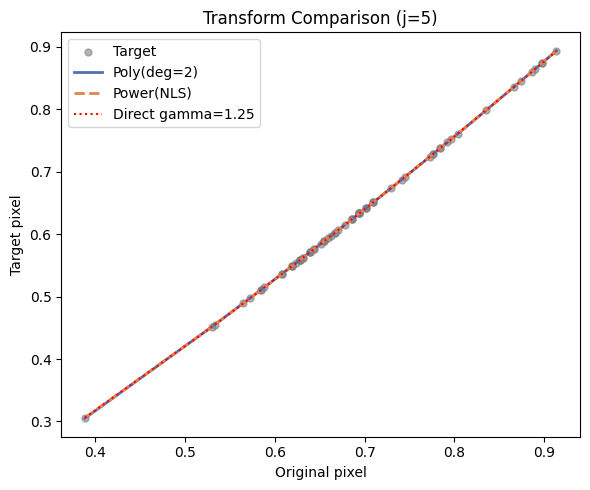

In [5]:
small_block = X_orig_block[:, :50]
small_hat   = X_hat_block[:, :50]

print("Fitting power transform...")
params_power = fit_block_transform(small_block, small_hat, use_nonlinear=True)
print(f"Power params shape={params_power.shape}")
print("First 5 (alpha_j, gamma_j):")
print(params_power[:5])

X_trans_power = apply_block_transform_batch(small_block, params_power, use_nonlinear=True)
mse_poly  = float(np.mean((X_transformed_poly[:, :50] - small_hat)**2))
mse_power = float(np.mean((X_trans_power - small_hat)**2))
mse_gamma = float(np.mean((X_transformed_gamma[:, :50] - small_hat)**2))
print(f"Poly MSE:   {mse_poly:.6f}")
print(f"Power MSE:  {mse_power:.6f}")
print(f"Direct Gamma MSE: {mse_gamma:.6f}")

feat_j = 5
z = small_block[:, feat_j]
sort_idx = np.argsort(z)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(z, small_hat[:, feat_j], alpha=0.6, s=25, color="gray", label="Target")
ax.plot(z[sort_idx], X_transformed_poly[:, feat_j][sort_idx], color="#4c72b0", lw=2, label="Poly(deg=2)")
ax.plot(z[sort_idx], X_trans_power[:, feat_j][sort_idx], color="#dd8452", lw=2, ls="--", label="Power(NLS)")
ax.plot(z[sort_idx], X_transformed_gamma[:, feat_j][sort_idx], color="red", lw=1.5, ls=":", label=f"Direct gamma={gamma_ab:.2f}")
ax.set_xlabel("Original pixel")
ax.set_ylabel("Target pixel")
ax.set_title(f"Transform Comparison (j={feat_j})")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/03_poly_vs_power.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. 全局变换学习（精确 Gamma）

In [6]:
print("Learning all-block transforms with exact gamma storage...")
transform_params = fit_all_transforms(
    X_train, X_hat_train,
    row_labels=bicluster.row_labels_,
    col_labels=bicluster.col_labels_,
    n_row_clusters=4, n_col_clusters=4,
    degree=2, use_nonlinear=False,
    block_params=block_params
)
print(f"Learned {len(transform_params)} blocks")
print("Gamma values per block:")
for (i, j), entry in sorted(transform_params.items()):
    print(f"  ({i},{j}): gamma={entry['gamma']}")

Learning all-block transforms with exact gamma storage...


Learned 16 blocks
Gamma values per block:
  (0,0): gamma=0.9829325545923785
  (0,1): gamma=1.651817006530904
  (0,2): gamma=0.7400518451496362
  (0,3): gamma=1.199499694587673
  (1,0): gamma=0.9025627022618476
  (1,1): gamma=1.117594244102009
  (1,2): gamma=0.802883038513073
  (1,3): gamma=0.9002101199398618
  (2,0): gamma=1.1225919046944661
  (2,1): gamma=1.587335793881886
  (2,2): gamma=0.5984584163056438
  (2,3): gamma=1.1531523281087206
  (3,0): gamma=1.0404161607436122
  (3,1): gamma=1.8734626331103774
  (3,2): gamma=0.6236614735838468
  (3,3): gamma=1.2518352428698902


In [7]:
X_train_out = apply_all_transforms(
    X_train,
    row_labels=bicluster.row_labels_,
    col_labels=bicluster.col_labels_,
    transform_params=transform_params,
    n_row_clusters=4, n_col_clusters=4,
    use_direct_gamma=True
)
mse_out = float(np.mean((X_train_out - X_hat_train)**2))
print(f"Direct Gamma applied to train: MSE vs target = {mse_out:.8f}")
print("(Should be ~0 since Direct Gamma IS the reconstruction)")

Direct Gamma applied to train: MSE vs target = 0.00000000
(Should be ~0 since Direct Gamma IS the reconstruction)
